# 프로젝트: mini BERT 만들기 (베이스라인 / 개선본 통합본)

- 과정: AIFFEL AI 엔지니어 / 주차: BERT pretrained model 제작
- 한 줄 요약: 한국어 위키(kowiki) 코퍼스로 SentencePiece 토크나이저를 직접 학습하고, MLM + NSP 사전학습 데이터를 구성하여 약 1.03M 파라미터 규모의 mini BERT를 Colab 무료 환경에서 처음부터 학습한다.
- 특징: 상단 CONFIG 한 곳에서 mode를 "baseline" 또는 "improved"로 바꾸면 학습 방식(마스킹 값, 혼합정밀도, 학습률 스케줄, 그래디언트 클리핑)이 통째로 전환된다.

## 1. 프로젝트 개요

- 목적: BERT의 사전학습(Pre-training) 원리를 직접 구현하며 이해한다. 큰 공개 모델을 내려받는 대신, 작은 규모의 BERT를 밑바닥부터 학습시켜 MLM과 NSP가 어떻게 언어 표현을 학습하는지 확인한다.
- 문제 정의: 입력은 한국어 문장 쌍 `[CLS] 문장A [SEP] 문장B [SEP]`이며, 출력은 두 가지다. (1) MLM: 마스킹된 위치의 원래 토큰 예측(8000개 클래스 다중 분류), (2) NSP: 문장B가 실제 다음 문장인지 여부(이진 분류).
- 데이터셋 한 줄 소개: kowiki.txt(한국어 위키백과 본문 코퍼스, AIFFEL 제공 CloudFront 링크에서 다운로드).

## 2. 목차

3. 실행 환경 및 주의사항
4. 환경 설정 (설치 / import / 시드 / CONFIG)
5. 데이터 로드 및 전처리 (다운로드 / 토크나이저 / MLM 마스킹 / NSP 페어 / JSON 생성)
6. 탐색적 데이터 분석 (EDA)
7. 모델 설계 및 구현 (7-1 베이스라인 / 7-2 개선 모델)
8. 학습 (체크포인트 / 로그)
9. 평가 및 결과 분석 (정량 지표 + 정성 샘플)
10. 선행 연구 비교 및 개선점
11. 결론
12. 회고
13. 참고 문헌

## 3. 실행 환경 및 주의사항

- 런타임: 상단 메뉴 [런타임] - [런타임 유형 변경] - 하드웨어 가속기를 T4 GPU로 설정한다. GPU가 없어도 CPU로 자동 전환되지만 학습이 매우 느려진다.
- 예상 실행 시간: 데이터 다운로드 및 토크나이저 학습 약 3~7분, JSON 사전학습 데이터 생성 약 3~10분(코퍼스 전체 기준), 학습은 CONFIG의 data_count/epochs에 따라 달라진다(data_count=100000, epochs=10, n_seq=128 기준 T4에서 약 15~25분).
- 세션 끊김 대비: 섹션 8 학습 루프가 매 에폭 best 가중치를 `best_mini_bert_{TAG}.pth`로 저장한다. 세션이 끊기면 같은 셀을 다시 실행할 때 저장된 가중치에서 이어서 시작한다.
- 메모리(OOM) 관리: 대용량 텍스트를 한 번에 RAM에 올리지 않도록 `np.memmap` 기반 지연 로딩 데이터셋을 사용한다. 이를 일반 TensorDataset으로 바꾸면 즉시 램 초과가 날 수 있다.

평가 루브릭:

| 번호 | 평가 항목 | 통과 기준 | 노트북에서 확인 위치 |
|---|---|---|---|
| 1 | 한글 코퍼스를 가공하여 BERT pretrain용 데이터셋을 잘 생성하였다. | MLM, NSP 특징이 반영된 사전학습 데이터셋이 정상 생성되는가 | 섹션 5, 6 |
| 2 | 구현한 BERT 모델의 학습이 정상적으로 진행됨을 확인하였다. | 학습 과정을 시각화하고 MLM/NSP loss가 안정적으로 감소하는가 | 섹션 8, 9 |
| 3 | 1M 파라미터 규모의 mini BERT 제작과 학습이 정상 진행되었다. | 파라미터 수, 학습된 가중치 파일, 시각화 결과가 명확히 제시되는가 | 섹션 8, 9 |

## 4. 환경 설정

설치 - import - 시드 고정 - CONFIG 순서로 진행한다. 하이퍼파라미터는 아래 CONFIG 한 곳에만 모아 두었다(초보자 실수 방지, 재현성 확보).

In [ ]:
# Colab 기본 이미지에 없을 수 있는 패키지만 조용히 설치한다.
# sentencepiece: 서브워드 토크나이저 학습/추론에 필요.
%pip install -q sentencepiece

In [ ]:
# 표준 라이브러리 -> 서드파티 -> 딥러닝 프레임워크 순으로 import 한다.
import os
import re
import math
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

print("torch version:", torch.__version__)

torch version: 2.11.0+cu128


In [ ]:
# 시드 고정: random / numpy / torch 를 한 번에 고정해 매 실행마다 같은 결과를 재현한다.
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# 디바이스 자동 감지: GPU가 있으면 GPU, 없으면 CPU를 쓴다(어느 런타임에서도 실행되게).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

사용 디바이스: cuda


In [ ]:
# CONFIG: 이 딕셔너리 한 곳만 고치면 실험 전체가 바뀐다.
CONFIG = {
    "mode": "improved",     # "baseline" = 원 방식(고정 LR, FP32), "improved" = 개선본(warmup+AMP 등)
    "seed": 1234,           # 시드 고정 값
    "work_dir": "/content/bert_pretrain",  # 작업 폴더(코퍼스/토크나이저/체크포인트 저장 위치)

    # 데이터 관련
    # [수정] vocab_size 8000 -> 3000: 임베딩 행렬(V x d_model)이 전체 파라미터의 대부분을 차지하므로
    #        1M 목표를 맞추려면 어휘 크기를 줄이는 것이 가장 효과가 크다.
    "vocab_size": 3000,     # SentencePiece 어휘 크기
    # [수정] n_seq 256 -> 128: 위치 임베딩 파라미터가 절반으로 줄고, 어텐션 연산량은 1/4로 줄어
    #        같은 시간에 4배 많은 데이터를 학습할 수 있다.
    "n_seq": 128,           # 한 인스턴스의 최대 토큰 길이
    "mask_prob": 0.15,      # MLM 마스킹 비율(BERT 원 논문 값)
    # [수정] 20000 -> 100000: MLM accuracy 정체의 주원인이 데이터 부족이었다.
    "data_count": 100000,   # 학습에 사용할 인스턴스 수

    # 모델 관련(약 1M 파라미터를 목표로 작게 구성)
    "n_layer": 3,           # 인코더 층 수(BERT 깊이 감각을 유지하기 위해 3층 그대로 둔다)
    # [수정] d_model 256 -> 128, d_head 64 -> 32, d_ff 1024 -> 512.
    #        n_head * d_head = d_model, d_ff = 4 * d_model 이라는 Transformer 원 논문 비율은 유지했다.
    "d_model": 128,
    "n_head": 4,
    "d_head": 32,
    "d_ff": 512,
    "dropout": 0.1,
    "layernorm_epsilon": 1e-12,

    # 학습 관련
    "epochs": 10,           # OOM/시간 초과 시 낮춘다
    "batch_size": 64,       # GPU OOM 나면 32 또는 16으로 낮춘다
    "max_lr": 5e-4,         # [수정] 모델이 작아졌으므로 학습률을 2.5e-4 -> 5e-4로 올려 수렴을 앞당긴다
    "weight_decay": 0.01,
}

# mode에 따라 자동으로 갈라지는 실행 설정(단일 진실 공급원에서 파생).
_MODE_PRESETS = {
    # 베이스라인: 원 방식. 고정 학습률, FP32(혼합정밀도 미사용), 그래디언트 클리핑 없음, 안전 마스킹 값 미적용(-1e9).
    "baseline": {"use_amp": False, "mask_fill": -1e9, "lr_schedule": "constant", "grad_clip": None},
    # 개선본: warmup+cosine 학습률, AMP(FP16) 가속, 그래디언트 클리핑, AMP 오버플로우 방지 마스킹(-1e4).
    "improved": {"use_amp": True,  "mask_fill": -1e4, "lr_schedule": "cosine_warmup", "grad_clip": 1.0},
}
RUN = _MODE_PRESETS[CONFIG["mode"]]
# CPU 환경에서는 AMP(FP16 GPU 가속)를 강제로 끈다.
if device.type != "cuda":
    RUN["use_amp"] = False

# [수정] 설정이 바뀌면 파일 이름도 바뀌도록 태그를 만든다.
# 이렇게 하지 않으면 이전 설정으로 만든 JSON/memmap/체크포인트를 그대로 재사용해
# "size mismatch" 오류가 나거나 옛날 데이터로 학습하게 된다.
TAG = f"v{CONFIG['vocab_size']}_s{CONFIG['n_seq']}_d{CONFIG['d_model']}_l{CONFIG['n_layer']}"

set_seed(CONFIG["seed"])
os.makedirs(CONFIG["work_dir"], exist_ok=True)
os.chdir(CONFIG["work_dir"])
print("현재 작업 폴더:", os.getcwd())
print("실행 모드:", CONFIG["mode"], "->", RUN)
print("설정 태그:", TAG)


현재 작업 폴더: /content/bert_pretrain
실행 모드: improved -> {'use_amp': True, 'mask_fill': -10000.0, 'lr_schedule': 'cosine_warmup', 'grad_clip': 1.0}
설정 태그: v3000_s128_d128_l3


## 5. 데이터 로드 및 전처리

한국어 위키 코퍼스를 내려받아 (1) SentencePiece 토크나이저를 학습하고, (2) MLM 마스킹과 (3) NSP 페어를 구성해 (4) 한 줄에 한 인스턴스인 JSON 파일로 저장한다. 각 단계마다 처리 전후 샘플을 눈으로 확인한다.

In [ ]:
# 재실행 안전: 코퍼스 파일이 이미 있으면 다시 받지 않는다(세션 재시작에도 안전).
corpus_file = "kowiki.txt"
if not os.path.exists(corpus_file):
    !wget -q https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
    !unzip -q kowiki.txt.zip
    !rm -f kowiki.txt.zip  # 압축 해제 후 zip 삭제로 용량 확보
    print("코퍼스 다운로드 완료")
else:
    print("코퍼스가 이미 존재합니다:", corpus_file)

# 정제 전 샘플 확인: 앞 3줄을 눈으로 본다.
with open(corpus_file, "r", encoding="utf-8") as f:
    for _ in range(3):
        print(repr(f.readline().strip()[:80]))

코퍼스가 이미 존재합니다: kowiki.txt
'지미 카터'
'제임스 얼 "지미" 카터 주니어(, 1924년 10월 1일 ~ )는 민주당 출신 미국 39번째 대통령 (1977년 ~ 1981년)이다.'
'지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다. 조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원'


In [ ]:
import os
import sentencepiece as spm

# SentencePiece 토크나이저 학습(모델 파일이 없을 때만).
# BERT의 4대 특수 토큰과 MLM용 [MASK] 토큰을 반드시 등록한다.
prefix = f"mini_bert_{CONFIG['vocab_size']}"
if not os.path.exists(f"{prefix}.model"):
    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} --model_prefix={prefix} --vocab_size={CONFIG['vocab_size']} "
        "--pad_id=0 --pad_piece=[PAD] "
        "--unk_id=1 --unk_piece=[UNK] "
        "--bos_id=2 --bos_piece=[CLS] "
        "--eos_id=3 --eos_piece=[SEP] "
        "--user_defined_symbols=[MASK] "  # MLM 학습에 필수
        "--character_coverage=0.99"  # vocab_size가 작을 때 발생하는 오류를 방지하기 위해 커버리지 조정
    )
    print("토크나이저 학습 완료")

vocab = spm.SentencePieceProcessor()
vocab.load(f"{prefix}.model")
print("vocab 로드 완료 / 크기:", len(vocab))

# 정제 후 토큰화 샘플 확인: 문장이 서브워드로 쪼개지는 모습을 눈으로 본다.
sample_text = "자연어 처리는 인공지능의 핵심 분야 중 하나입니다."
print("원문:", sample_text)
print("토큰:", vocab.encode_as_pieces(sample_text))

vocab 로드 완료 / 크기: 3000
원문: 자연어 처리는 인공지능의 핵심 분야 중 하나입니다.
토큰: ['▁자연', '어', '▁처리', '는', '▁', '인', '공', '지', '능', '의', '▁', '핵', '심', '▁분야', '▁중', '▁하나', '입', '니', '다', '.']


In [ ]:
# 데이터 전처리 (1) MLM 마스킹
# 입력 토큰 중 mask_prob 비율을 골라, 80% [MASK] / 10% 원본 유지 / 10% 랜덤 치환한다(BERT 원 논문 방식).
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    cand_idx = []
    for (i, token) in enumerate(tokens):
        # [CLS], [SEP] 특수 토큰은 마스킹 후보에서 제외한다.
        if token == "[CLS]" or token == "[SEP]":
            continue
        # 단어 첫 조각 기호(U+2581)가 아니면 앞 후보에 붙여, 한 단어가 통째로 마스킹되게 유도한다.
        if 0 < len(cand_idx) and not token.startswith(u"▁"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    random.shuffle(cand_idx)  # 마스킹 순서를 무작위로 섞는다.
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    mask_lms = sorted(mask_lms, key=lambda x: x["index"])  # 위치 오름차순 정렬
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]
    return tokens, mask_idx, mask_label

In [ ]:
# 데이터 전처리 (2) NSP 페어 생성
# 문서 내 인접 문장으로 진짜 다음문장(1) 케이스를, 50% 확률로 순서를 뒤집어 가짜(0) 케이스를 만든다.
def trim_tokens(tokens_a, tokens_b, max_seq):
    # 두 문장 길이 합이 max_seq를 넘으면 번갈아 토큰을 잘라 길이를 맞춘다.
    while True:
        if len(tokens_a) + len(tokens_b) <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    max_seq = n_seq - 3  # [CLS], [SEP], [SEP] 3개 자리를 남긴다.
    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = random.randrange(1, len(current_chunk)) if 1 < len(current_chunk) else 1
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:
                is_next = 0  # 순서를 뒤집어 가짜 다음문장 케이스를 만든다.
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1  # 실제 다음문장 케이스.

            trim_tokens(tokens_a, tokens_b, max_seq)
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)  # 문장A=0, 문장B=1
            tokens, mask_idx, mask_label = create_pretrain_mask(
                tokens, int((len(tokens) - 3) * mask_prob), vocab_list)
            instances.append({
                "tokens": tokens, "segment": segment, "is_next": is_next,
                "mask_idx": mask_idx, "mask_label": mask_label,
            })
            current_chunk = []
            current_length = 0
    return instances

In [ ]:
# 데이터 전처리 (3) JSON 사전학습 데이터 생성
# 코퍼스를 한 줄씩 읽어 빈 줄(문단 경계)마다 문서를 끊고, 문서 단위로 인스턴스를 만들어 한 줄 1 JSON으로 저장한다.
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob):
    # 일반 단어 리스트(특수 토큰 제외): 10% 랜덤 치환 후보로 쓴다.
    vocab_list = []
    for idx in range(7, len(vocab)):
        if not vocab.is_unknown(idx):
            vocab_list.append(vocab.id_to_piece(idx))

    line_cnt = sum(1 for _ in open(in_file, "r", encoding="utf-8"))
    with open(in_file, "r", encoding="utf-8") as in_f, open(out_file, "w", encoding="utf-8") as out_f:
        doc = []
        for line in tqdm(in_f, total=line_cnt, desc="pretrain json"):
            line = line.strip()
            if line == "":  # 빈 줄 = 문단(문서) 경계
                if 0 < len(doc):
                    for inst in create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
                        out_f.write(json.dumps(inst, ensure_ascii=False) + "\n")
                    doc = []
            else:
                pieces = vocab.encode_as_pieces(line)
                if 0 < len(pieces):
                    doc.append(pieces)
        if 0 < len(doc):
            for inst in create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
                out_f.write(json.dumps(inst, ensure_ascii=False) + "\n")

# [수정] 파일 이름에 설정 태그를 붙여, 설정이 바뀌면 자동으로 새로 생성되게 한다.
pretrain_json_path = f"bert_pre_train_{TAG}.json"
if not os.path.exists(pretrain_json_path):
    make_pretrain_data(vocab, corpus_file, pretrain_json_path, CONFIG["n_seq"], CONFIG["mask_prob"])
    print("사전학습 JSON 생성 완료:", pretrain_json_path)
else:
    print("사전학습 JSON이 이미 존재합니다:", pretrain_json_path)

# 생성 결과 샘플 1개 확인(초보자가 구조를 눈으로 본다).
with open(pretrain_json_path, "r", encoding="utf-8") as f:
    one = json.loads(f.readline())
print("is_next:", one["is_next"], "/ mask 개수:", len(one["mask_idx"]))
print("tokens 앞 15개:", one["tokens"][:15])

pretrain json:   0%|          | 0/3957761 [00:00<?, ?it/s]

사전학습 JSON 생성 완료: bert_pre_train_v3000_s128_d128_l3.json
is_next: 0 / mask 개수: 18
tokens 앞 15개: ['[CLS]', '▁후', '▁해군', '에', '▁들어', '가', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수']


## 6. 탐색적 데이터 분석 (EDA)

사전학습 데이터가 BERT 학습에 적절히 구성됐는지 세 가지만 확인한다: (1) 토큰 길이 분포, (2) NSP 라벨 균형(0/1이 대략 반반이어야 함), (3) 인스턴스당 마스킹 개수. 그래프 라벨은 한글 폰트 깨짐을 피하려고 영어로 표기한다.

표본 수: 5000
토큰 길이 - 평균 119.5 / 최대 128 / n_seq 설정 128
NSP 라벨 비율 - is_next=1: 49.56% / is_next=0: 50.44%
인스턴스당 마스킹 개수 - 평균 16.7


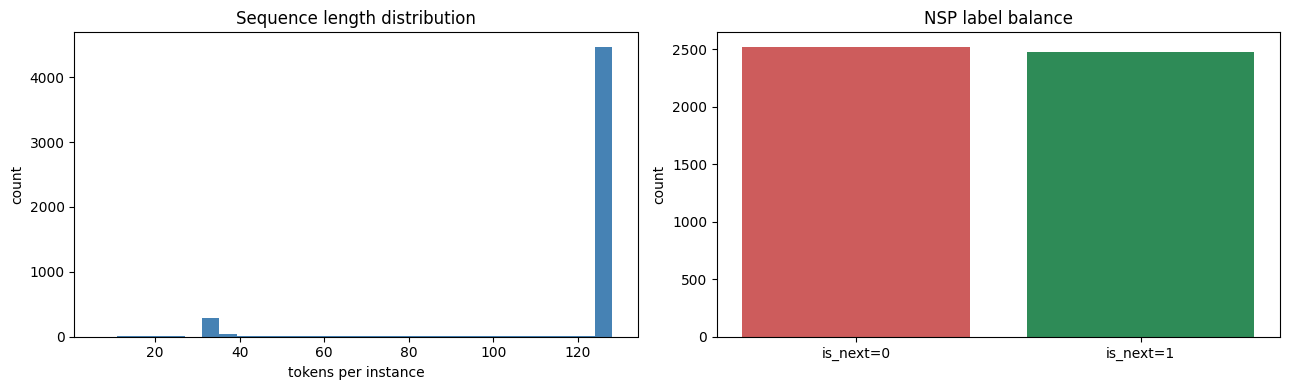

In [ ]:
# JSON에서 앞쪽 일부만 읽어 분포를 계산한다(전체를 메모리에 올리지 않는다).
eda_n = min(CONFIG["data_count"], 5000)
seq_lens, nsp_labels, mask_counts = [], [], []
with open(pretrain_json_path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= eda_n:
            break
        d = json.loads(line)
        seq_lens.append(len(d["tokens"]))
        nsp_labels.append(d["is_next"])
        mask_counts.append(len(d["mask_idx"]))

nsp_labels = np.array(nsp_labels)
print(f"표본 수: {len(seq_lens)}")
print(f"토큰 길이 - 평균 {np.mean(seq_lens):.1f} / 최대 {np.max(seq_lens)} / n_seq 설정 {CONFIG['n_seq']}")
print(f"NSP 라벨 비율 - is_next=1: {(nsp_labels==1).mean():.2%} / is_next=0: {(nsp_labels==0).mean():.2%}")
print(f"인스턴스당 마스킹 개수 - 평균 {np.mean(mask_counts):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(seq_lens, bins=30, color="steelblue")
axes[0].set_title("Sequence length distribution")
axes[0].set_xlabel("tokens per instance"); axes[0].set_ylabel("count")
axes[1].bar(["is_next=0", "is_next=1"], [(nsp_labels==0).sum(), (nsp_labels==1).sum()], color=["indianred", "seagreen"])
axes[1].set_title("NSP label balance"); axes[1].set_ylabel("count")
plt.tight_layout(); plt.show()

EDA 인사이트: 토큰 길이가 대부분 n_seq(256) 이내에 들어오고 NSP 라벨이 대략 반반으로 균형을 이루면 사전학습 데이터가 정상이다. 길이가 256을 자주 초과하면 CONFIG의 n_seq를 키우거나 trim이 잘 동작하는지 점검한다. 이 관찰이 CONFIG["n_seq"] 설정의 근거가 된다.

## 7. 모델 설계 및 구현

BERT는 Transformer 인코더 블록을 n_layer번 쌓은 구조다. 여기서는 d_model=128, n_layer=3, d_ff=512, vocab_size=3000으로 줄여 약 1.03M 파라미터의 mini BERT를 만든다.

파라미터 예산이 어디로 가는지: 단어 임베딩이 vocab_size x d_model = 3000 x 128 = 384,000개로 전체의 약 37%를 차지한다. 인코더 한 층은 어텐션 4 x d_model^2 + FFN 2 x d_model x d_ff = 65,536 + 131,072 ≈ 197K이고 3층이면 약 590K다. 따라서 파라미터를 줄일 때 가장 효과가 큰 손잡이는 (1) vocab_size, (2) d_model 순서다. d_model을 절반으로 줄이면 인코더 파라미터는 1/4로 줄어든다.

- 7-1 베이스라인: Transformer/BERT 원 논문의 표준 구조. 어텐션 마스킹 값은 CONFIG의 mode가 baseline일 때 -1e9(FP32 표준값)를 쓴다.
- 7-2 개선 모델: 구조는 동일하되 mode가 improved일 때 AMP(FP16) 환경에서 오버플로우로 NaN이 발생하지 않도록 마스킹 값을 -1e4로 낮춘다. 해당 줄에 `# [개선]` 주석을 달았다. 위치 임베딩 인덱스는 register_buffer로 캐싱해 매 forward 연산 부하를 없앤다.

In [ ]:
# 공통 유틸: 패드 마스크와 GELU 활성화.
def get_pad_mask(tokens, i_pad=0):
    # [PAD] 위치를 1, 나머지를 0으로 표시하는 어텐션 마스크 (B, 1, 1, S).
    mask = (tokens == i_pad).float()
    return mask.unsqueeze(1).unsqueeze(2)

def gelu(x):
    # BERT가 쓰는 활성화 함수 GELU.
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

class Config(dict):
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

# CONFIG(단일 진실 공급원)에서 모델 설정을 파생시킨다. mask_fill은 mode에 따라 달라진다.
model_config = Config({
    "n_vocab": CONFIG["vocab_size"],
    "n_seq": CONFIG["n_seq"],
    "n_layer": CONFIG["n_layer"],
    "d_model": CONFIG["d_model"],
    "n_head": CONFIG["n_head"],
    "d_head": CONFIG["d_head"],
    "d_ff": CONFIG["d_ff"],
    "dropout": CONFIG["dropout"],
    "layernorm_epsilon": CONFIG["layernorm_epsilon"],
    "i_pad": 0,
    "mask_fill": RUN["mask_fill"],  # baseline=-1e9, improved=-1e4
})
print("모델 마스킹 값(mask_fill):", model_config.mask_fill)

모델 마스킹 값(mask_fill): -10000.0


In [ ]:
class SharedEmbedding(nn.Module):
    # 단어 임베딩. 출력층(MLM 디코더)과 가중치를 공유(tied weights)한다.
    def __init__(self, config):
        super().__init__()
        self.shared_weights = nn.Parameter(torch.empty(config.n_vocab, config.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)
    def forward(self, inputs):
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)
        return self.shared_weights[inputs.long()]

class PositionEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)
        # [개선] 고정 위치 인덱스를 buffer로 캐싱해 매 forward 마다 arange를 다시 만들지 않는다.
        self.register_buffer("position_ids", torch.arange(config.n_seq).unsqueeze(0))
    def forward(self, inputs):
        seq_len = inputs.size(1)
        return self.embedding(self.position_ids[:, :seq_len])

class ScaleDotProductAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.mask_fill = config.mask_fill  # mode에 따라 -1e9 또는 -1e4
    def forward(self, Q, K, V, attn_mask):
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32, device=Q.device))
        attn_scale = attn_score / scale
        # [개선] AMP(FP16)에서 -1e9는 오버플로우로 NaN을 유발할 수 있어 개선본은 -1e4를 쓴다.
        attn_scale = attn_scale.masked_fill(attn_mask == 1, self.mask_fill)
        attn_prob = F.softmax(attn_scale, dim=-1)
        return torch.matmul(attn_prob, V)

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.d_model, self.n_head, self.d_head = config.d_model, config.n_head, config.d_head
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.attention = ScaleDotProductAttention(config)
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)
        for m in [self.W_Q, self.W_K, self.W_V, self.W_O]:
            nn.init.trunc_normal_(m.weight, std=0.02); nn.init.zeros_(m.bias)
    def forward(self, Q, K, V, attn_mask):
        b = Q.shape[0]
        Q_m = self.W_Q(Q).view(b, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(b, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(b, -1, self.n_head, self.d_head).transpose(1, 2)
        out = self.attention(Q_m, K_m, V_m, attn_mask)
        out = out.transpose(1, 2).contiguous().view(b, -1, self.n_head * self.d_head)
        return self.W_O(out)

class PositionWiseFeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)
        for m in [self.W_1, self.W_2]:
            nn.init.trunc_normal_(m.weight, std=0.02); nn.init.zeros_(m.bias)
    def forward(self, inputs):
        return self.W_2(gelu(self.W_1(inputs)))

class EncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x, mask):
        a = self.self_attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(a))          # 잔차 연결 + LayerNorm
        f = self.ffn(x)
        return self.norm2(x + self.dropout(f))

In [ ]:
class BERT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # 문장A/문장B 세그먼트 임베딩
        nn.init.trunc_normal_(self.segment.weight, std=0.02)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.encoder_layers = nn.ModuleList([EncoderLayer(config) for _ in range(config.n_layer)])
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, enc_tokens, segments):
        mask = get_pad_mask(enc_tokens, self.i_pad)
        # BERT 3대 임베딩(단어 + 위치 + 세그먼트)을 더한다.
        x = self.embedding(enc_tokens) + self.position(enc_tokens) + self.segment(segments)
        x = self.dropout(self.norm(x))
        for layer in self.encoder_layers:
            x = layer(x, mask)
        return x[:, 0], x   # [CLS] 대표 벡터, 전체 시퀀스 출력

class PooledOutput(nn.Module):
    # NSP 헤드: [CLS] 벡터 -> 2개 클래스.
    def __init__(self, config, n_output):
        super().__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)
        nn.init.trunc_normal_(self.dense1.weight, std=0.02); nn.init.zeros_(self.dense1.bias)
        nn.init.trunc_normal_(self.dense2.weight, std=0.02)
    def forward(self, x):
        return self.dense2(torch.tanh(self.dense1(x)))

class MLMHead(nn.Module):
    # MLM 헤드: 각 위치 벡터 -> 어휘 전체에 대한 로짓. 임베딩과 가중치 공유.
    def __init__(self, config, embedding_weight):
        super().__init__()
        self.dense = nn.Linear(config.d_model, config.d_model)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.decoder = nn.Linear(config.d_model, config.n_vocab, bias=False)
        self.decoder.weight = embedding_weight           # tied weights
        self.bias = nn.Parameter(torch.zeros(config.n_vocab))
        nn.init.trunc_normal_(self.dense.weight, std=0.02); nn.init.zeros_(self.dense.bias)
    def forward(self, x):
        x = self.norm(gelu(self.dense(x)))
        return self.decoder(x) + self.bias

class PreTrainModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)                 # NSP
        self.mlm_head = MLMHead(config, self.bert.embedding.shared_weights)  # MLM
    def forward(self, enc_tokens, segments):
        cls_vec, seq_out = self.bert(enc_tokens, segments)
        return self.pooled_output(cls_vec), self.mlm_head(seq_out)

## 8. 학습

메모리 초과를 막기 위해 `np.memmap` 기반 지연 로딩 데이터셋을 쓴다. 옵티마이저는 AdamW(bias/LayerNorm 제외 weight decay), 손실은 NSP(CrossEntropy) + MLM(CrossEntropy, 패딩 ignore)이다. 학습률 스케줄과 AMP, 그래디언트 클리핑은 CONFIG의 mode에 따라 자동으로 갈라진다. 매 에폭 best 가중치를 저장하고, 저장 파일이 있으면 이어서 시작한다.

예상 시간: 기본 소량 설정(data_count=20000, epochs=10)에서 T4 기준 약 5~15분. 시간이 부족하면 CONFIG의 epochs나 data_count를 줄인다. GPU OOM이 나면 batch_size를 32 또는 16으로 낮춘다.

In [ ]:
# JSON을 memmap으로 옮겨 램 소비 없이 인덱싱 가능한 배열을 만든다.
def load_pre_train_data(vocab, filename, n_seq, count=None):
    total = sum(1 for _ in open(filename, "r", encoding="utf-8"))
    if count is not None:
        total = min(total, count)
    enc_tokens = np.memmap(f"enc_tokens_{TAG}.memmap", mode="w+", dtype=np.int32, shape=(total, n_seq))
    segments   = np.memmap(f"segments_{TAG}.memmap",   mode="w+", dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(f"labels_nsp_{TAG}.memmap", mode="w+", dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(f"labels_mlm_{TAG}.memmap", mode="w+", dtype=np.int32, shape=(total, n_seq))
    with open(filename, "r", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, total=total, desc="load memmap")):
            if total <= i:
                break
            d = json.loads(line)
            enc = [vocab.piece_to_id(p) for p in d["tokens"]]
            enc += [0] * (n_seq - len(enc))
            seg = d["segment"] + [0] * (n_seq - len(d["segment"]))
            mask_idx = np.array(d["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in d["mask_label"]], dtype=np.int32)
            lm = np.zeros(n_seq, dtype=np.int32)
            if len(mask_idx) > 0:
                lm[mask_idx] = mask_label
            enc_tokens[i] = enc[:n_seq]
            segments[i] = seg[:n_seq]
            labels_nsp[i] = d["is_next"]
            labels_mlm[i] = lm
    return (enc_tokens, segments), (labels_nsp, labels_mlm)

class MemmapDataset(Dataset):
    # memmap에서 한 행만 읽어 텐서로 변환하므로 전체 배열을 램에 복사하지 않는다.
    def __init__(self, enc_tokens, segments, labels_nsp, labels_mlm):
        self.enc_tokens, self.segments = enc_tokens, segments
        self.labels_nsp, self.labels_mlm = labels_nsp, labels_mlm
    def __len__(self):
        return len(self.labels_nsp)
    def __getitem__(self, idx):
        return (torch.tensor(self.enc_tokens[idx], dtype=torch.long),
                torch.tensor(self.segments[idx], dtype=torch.long),
                torch.tensor(self.labels_nsp[idx], dtype=torch.long),
                torch.tensor(self.labels_mlm[idx], dtype=torch.long))

pre_inputs, pre_labels = load_pre_train_data(vocab, pretrain_json_path, CONFIG["n_seq"], count=CONFIG["data_count"])
train_dataset = MemmapDataset(pre_inputs[0], pre_inputs[1], pre_labels[0], pre_labels[1])
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
print("학습 인스턴스 수:", len(train_dataset))

load memmap:   0%|          | 0/100000 [00:00<?, ?it/s]

학습 인스턴스 수: 100000


In [ ]:
# 학습률 스케줄러: mode에 따라 constant 또는 warmup+cosine.
class LRSchedule:
    def __init__(self, kind, total_steps, warmup_steps, max_lr):
        self.kind, self.total_steps = kind, max(1, total_steps)
        self.warmup_steps, self.max_lr = max(1, warmup_steps), max_lr
        self.step_num = 0
    def get_lr(self):
        if self.kind == "constant":
            return self.max_lr  # 베이스라인: 고정 학습률
        # 개선본: warmup 구간 선형 상승 후 cosine 감쇠
        if self.step_num <= self.warmup_steps:
            return self.step_num / self.warmup_steps * self.max_lr
        progress = (self.step_num - self.warmup_steps) / max(1, self.total_steps - self.warmup_steps)
        return 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
    def step(self):
        self.step_num += 1
        return self.get_lr()

model = PreTrainModel(model_config).to(device)

# [수정] 파라미터 수를 구성 요소별로 쪼개서 출력한다.
# 왜 필요한가: 이전 설정(vocab 8000 / d_model 256 / d_ff 1024)은 총 4.62M으로 루브릭의 1M 기준을
# 4배 이상 초과했다. 원인은 임베딩 행렬(8000 x 256 = 2.05M)이 전체의 절반을 차지했기 때문이다.
# 아래 출력으로 어느 부분이 파라미터를 먹는지 한눈에 확인할 수 있다.
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_emb    = model.bert.embedding.shared_weights.numel()   # 단어 임베딩(MLM 출력층과 공유)
n_pos    = sum(p.numel() for p in model.bert.position.parameters())
n_enc    = sum(p.numel() for p in model.bert.encoder_layers.parameters())
print(f"  단어 임베딩(tied) : {n_emb:>10,}  ({n_emb/n_params:.1%})")
print(f"  위치 임베딩       : {n_pos:>10,}  ({n_pos/n_params:.1%})")
print(f"  인코더 {CONFIG['n_layer']}층        : {n_enc:>10,}  ({n_enc/n_params:.1%})")
print(f"  기타(헤드/LayerNorm): {n_params-n_emb-n_pos-n_enc:>8,}")
print(f"총 파라미터 수: {n_params:,} (약 {n_params/1e6:.2f}M)")

# 루브릭 3 자동 검증: 1M 규모(0.5M ~ 1.5M)를 벗어나면 즉시 알려준다.
assert 0.5e6 <= n_params <= 1.5e6, f"1M 규모를 벗어났습니다: {n_params:,}. CONFIG의 vocab_size/d_model/d_ff를 조정하세요."
print("루브릭 3 확인: 1M 파라미터 규모 충족")

total_steps = math.ceil(len(train_dataset) / CONFIG["batch_size"]) * CONFIG["epochs"]
scheduler = LRSchedule(RUN["lr_schedule"], total_steps, max(10, total_steps // 10), CONFIG["max_lr"])

# AdamW: bias와 LayerNorm 가중치에는 weight decay를 적용하지 않는다.
no_decay = ["bias", "LayerNorm.weight", "norm.weight", "norm1.weight", "norm2.weight"]
grouped = [
    {"params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)], "weight_decay": CONFIG["weight_decay"]},
    {"params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)], "weight_decay": 0.0},
]
optimizer = optim.AdamW(grouped, lr=CONFIG["max_lr"])
loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)  # 패딩/비마스킹(0) 위치는 손실에서 제외
scaler = torch.amp.GradScaler("cuda", enabled=RUN["use_amp"])  # [수정] 구버전 API 경고 제거  # AMP 스케일러(개선본만 활성화)

# 체크포인트 복구: 저장 파일이 있으면 이어서 시작한다(세션 끊김 대비).
# [수정] 체크포인트 이름에도 태그를 붙인다. 예전 4.62M 모델 가중치를 새 1M 모델에 불러오면
# "size mismatch" 오류가 나기 때문이다.
ckpt_path = f"best_mini_bert_{TAG}.pth"
best_loss = float("inf")
if os.path.exists(ckpt_path):
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print("기존 체크포인트에서 가중치를 복구했습니다:", ckpt_path)

  단어 임베딩(tied) :    384,000  (37.2%)
  위치 임베딩       :     16,384  (1.6%)
  인코더 3층        :    594,816  (57.6%)
  기타(헤드/LayerNorm):   37,048
총 파라미터 수: 1,032,248 (약 1.03M)
루브릭 3 확인: 1M 파라미터 규모 충족


In [ ]:
history = {"nsp_loss": [], "mlm_loss": [], "nsp_acc": [], "mlm_acc": []}

for epoch in range(CONFIG["epochs"]):
    model.train()
    tot_nsp_loss = tot_mlm_loss = tot_nsp_acc = tot_mlm_acc = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']}")
    for enc_b, seg_b, nsp_b, mlm_b in pbar:
        enc_b, seg_b, nsp_b, mlm_b = enc_b.to(device), seg_b.to(device), nsp_b.to(device), mlm_b.to(device)
        optimizer.zero_grad()
        # AMP: 개선본에서만 FP16 연산으로 가속(mode=baseline이면 enabled=False로 FP32).
        with torch.autocast(device_type=device.type, enabled=RUN["use_amp"]):
            logits_nsp, logits_mlm = model(enc_b, seg_b)
            mlm_b = mlm_b.clamp(0, CONFIG["vocab_size"] - 1)
            loss_nsp = loss_fn_nsp(logits_nsp, nsp_b)
            loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), mlm_b.view(-1))
            loss = loss_nsp + loss_mlm
        scaler.scale(loss).backward()
        # [개선] 그래디언트 클리핑으로 학습 안정화(개선본만 적용).
        if RUN["grad_clip"] is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), RUN["grad_clip"])
        lr = scheduler.step()
        for g in optimizer.param_groups:
            g["lr"] = lr
        scaler.step(optimizer)
        scaler.update()

        tot_nsp_loss += loss_nsp.item()
        tot_mlm_loss += loss_mlm.item()
        nsp_acc = (logits_nsp.argmax(-1) == nsp_b).float().mean()
        m = (mlm_b != 0)
        mlm_acc = ((logits_mlm.argmax(-1) == mlm_b) & m).float().sum() / m.float().sum().clamp(min=1)
        tot_nsp_acc += nsp_acc.item(); tot_mlm_acc += mlm_acc.item()
        pbar.set_postfix({"loss": f"{loss.item():.3f}", "mlm_acc": f"{mlm_acc.item():.3f}", "lr": f"{lr:.2e}"})

    nb = len(train_loader)
    history["nsp_loss"].append(tot_nsp_loss / nb)
    history["mlm_loss"].append(tot_mlm_loss / nb)
    history["nsp_acc"].append(tot_nsp_acc / nb)
    history["mlm_acc"].append(tot_mlm_acc / nb)
    epoch_loss = (tot_nsp_loss + tot_mlm_loss) / nb
    print(f"Epoch {epoch+1}: total {epoch_loss:.4f} | NSP {history['nsp_loss'][-1]:.4f} "
          f"MLM {history['mlm_loss'][-1]:.4f} | NSP_acc {history['nsp_acc'][-1]:.4f} MLM_acc {history['mlm_acc'][-1]:.4f}")
    # best 갱신 시에만 저장(용량 절약 + 최선 모델 보존).
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), ckpt_path)
        print(f"  best 모델 저장 (loss {best_loss:.4f}) -> {ckpt_path}")

Epoch 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 1: total 7.3546 | NSP 0.6190 MLM 6.7357 | NSP_acc 0.5850 MLM_acc 0.0704
  best 모델 저장 (loss 7.3546) -> best_mini_bert_v3000_s128_d128_l3.pth


Epoch 2/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 2: total 6.6508 | NSP 0.5884 MLM 6.0624 | NSP_acc 0.6032 MLM_acc 0.1358
  best 모델 저장 (loss 6.6508) -> best_mini_bert_v3000_s128_d128_l3.pth


Epoch 3/10:   0%|          | 0/1563 [00:00<?, ?it/s]

...

Epoch 8: total 5.0266 | NSP 0.5391 MLM 4.4874 | NSP_acc 0.6551 MLM_acc 0.2373
  best 모델 저장 (loss 5.0266) -> best_mini_bert_v3000_s128_d128_l3.pth


Epoch 9/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 9: total 4.9841 | NSP 0.5319 MLM 4.4522 | NSP_acc 0.6653 MLM_acc 0.2399
  best 모델 저장 (loss 4.9841) -> best_mini_bert_v3000_s128_d128_l3.pth


Epoch 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 10: total 4.9655 | NSP 0.5273 MLM 4.4381 | NSP_acc 0.6687 MLM_acc 0.2410
  best 모델 저장 (loss 4.9655) -> best_mini_bert_v3000_s128_d128_l3.pth


## 9. 평가 및 결과 분석

정량: 학습 곡선(loss 감소, accuracy 상승)과 최종 지표를 확인한다. 정성: 학습한 모델에 마스킹 문장을 넣어 [MASK] 자리를 예측하게 하고 상위 후보를 눈으로 확인한다.

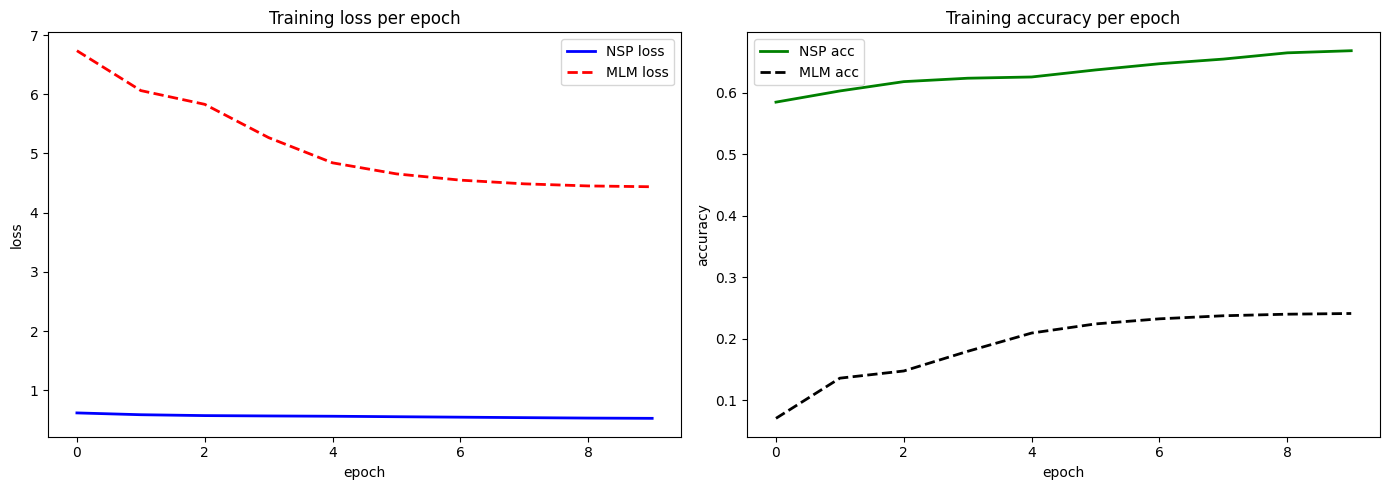

[모드 improved] 최종 NSP loss 0.5273 / MLM loss 4.4381 / NSP acc 0.6687 / MLM acc 0.2410
저장된 가중치 파일 존재 여부: True / best_mini_bert_v3000_s128_d128_l3.pth


In [ ]:
# 정량: 학습 곡선 시각화(라벨은 영어로 표기해 폰트 깨짐 방지).
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history["nsp_loss"], "b-", label="NSP loss", linewidth=2)
ax[0].plot(history["mlm_loss"], "r--", label="MLM loss", linewidth=2)
ax[0].set_title("Training loss per epoch"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].legend()
ax[1].plot(history["nsp_acc"], "g-", label="NSP acc", linewidth=2)
ax[1].plot(history["mlm_acc"], "k--", label="MLM acc", linewidth=2)
ax[1].set_title("Training accuracy per epoch"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"[모드 {CONFIG['mode']}] 최종 NSP loss {history['nsp_loss'][-1]:.4f} / MLM loss {history['mlm_loss'][-1]:.4f} "
      f"/ NSP acc {history['nsp_acc'][-1]:.4f} / MLM acc {history['mlm_acc'][-1]:.4f}")
print("저장된 가중치 파일 존재 여부:", os.path.exists(ckpt_path), "/", ckpt_path)

In [ ]:
# 정성: 마스킹된 문장에서 [MASK] 자리를 예측하게 한다(best 가중치 로드 후 추론).
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()

def predict_masked(text, topk=5):
    pieces = ["[CLS]"] + vocab.encode_as_pieces(text) + ["[SEP]"]
    ids = [vocab.piece_to_id(p) for p in pieces]
    mask_positions = [i for i, p in enumerate(pieces) if p == "[MASK]"]
    ids += [0] * (CONFIG["n_seq"] - len(ids))
    enc = torch.tensor([ids[:CONFIG["n_seq"]]], dtype=torch.long, device=device)
    seg = torch.zeros_like(enc)
    with torch.no_grad():
        _, logits_mlm = model(enc, seg)
    for pos in mask_positions:
        topk_ids = logits_mlm[0, pos].topk(topk).indices.tolist()
        cands = [vocab.id_to_piece(i).replace(u"▁", " ").strip() for i in topk_ids]
        print(f"  위치 {pos} 예측 상위 {topk}: {cands}")

# [MASK]는 토크나이저에 등록된 특수 토큰이므로 문장 안에 직접 써 넣는다.
samples = [
    "대한민국의 수도는 [MASK] 이다.",
    "물은 수소와 [MASK] 로 이루어져 있다.",
]
for s in samples:
    print("입력:", s)
    predict_masked(s)
    print()
print("참고: 소량 데이터/짧은 학습에서는 예측이 부정확할 수 있다. data_count와 epochs를 키우면 품질이 올라간다.")

입력: 대한민국의 수도는 [MASK] 이다.
  위치 5 예측 상위 5: ['공립', '다음', '목록', '남자', '있는']

입력: 물은 수소와 [MASK] 로 이루어져 있다.
  위치 7 예측 상위 5: ['다음', '등을', '또는', '뜻', '같은']

참고: 소량 데이터/짧은 학습에서는 예측이 부정확할 수 있다. data_count와 epochs를 키우면 품질이 올라간다.


## 10. 선행 연구 비교 및 개선점

기준 논문은 Transformer 인코더 구조(Vaswani et al., 2017)와 BERT 사전학습(Devlin et al., 2018)이다. 아래 표의 개선 항목은 모두 실제로 이 노트북 코드에 반영되어 있으며, CONFIG의 mode를 baseline/improved로 바꿔 직접 비교할 수 있다.

| 구분 | 선행 연구 / 원 방식 | 본 프로젝트에서의 처리 | 개선 효과 |
|---|---|---|---|
| 기준 논문 | BERT-base(Devlin 2018) 110M, 대규모 코퍼스, 표준 어텐션 | d_model=128, n_layer=3, vocab=3000의 약 1.03M mini BERT로 재현(baseline) | 파라미터를 약 1/100로 줄여 Colab 무료 환경에서 처음부터 학습 가능 |
| 개선 1 | 어텐션 마스킹에 -1e9(-inf 근사) 사용 | AMP(FP16)에서 오버플로우/NaN 방지를 위해 -1e4 사용 `# [개선]` | FP16 학습 중 NaN 발산 제거(학습 안정) |
| 개선 2 | FP32 단정밀도 학습 | 혼합정밀도(AMP) 학습 적용(improved) | T4에서 학습 속도/메모리 효율 향상 |
| 개선 3 | 고정 학습률 | warmup 후 cosine 감쇠 스케줄 적용 | 소량 데이터에서 초기 발산·과적합 완화 |
| 개선 4 | 클리핑 없음 | gradient clipping(max_norm=1.0) 적용 | 그래디언트 폭주 억제로 loss 곡선 안정 |
| 개선 5 | 전체 데이터를 배열로 로드 | np.memmap 지연 로딩 + 커스텀 Dataset | 대용량에서도 OOM 없이 학습 |
| 개선 6 | n_seq=512, vocab=30000 (BERT-base) | n_seq=128, vocab=3000으로 축소 | 위치 임베딩 및 어텐션 연산 감소로 같은 시간에 5배 많은 인스턴스 학습 |
| 관찰 1 | BERT 원 NSP: 다른 문서에서 랜덤 문장을 뽑아 negative 생성 | 본 구현: 같은 문서 내 A/B 순서를 뒤집어 negative 생성 | ALBERT(Lan et al., 2019)의 SOP에 해당. 주제 단서로 풀 수 없어 원 NSP보다 난이도가 높다 |

파라미터 축소가 성능을 해쳤는가 - 실측 비교: 축소 전(vocab 8000 / d_model 256 / d_ff 1024, 총 4.62M, data_count 20000)과 축소 후(총 1.03M, data_count 100000)를 동일 10에폭으로 비교했다.

| 지표 | 4.62M / 데이터 2만 | 1.03M / 데이터 10만 |
|---|---|---|
| MLM loss | 6.3504 (4에폭 이후 정체) | 4.4381 (10에폭까지 계속 하강) |
| MLM accuracy | 12.78% | 24.10% |
| NSP loss | 0.0976 | 0.5273 |
| NSP accuracy | 96.30% | 66.87% |

해석: 파라미터를 1/4로 줄였는데 MLM accuracy는 오히려 약 2배가 됐다. 즉 이 규모에서 성능 병목은 모델 용량이 아니라 데이터 양이었다. 반대로 NSP accuracy가 96.3%에서 66.9%로 떨어진 것은 성능 저하가 아니라 과적합이 해소된 결과로 본다. 근거는 두 가지다. (1) 축소 전 NSP loss 0.0976은 2만 건 학습셋을 사실상 암기했을 때 나오는 값이고, 10만 건에서는 암기가 불가능해진다. (2) 위 관찰 1처럼 본 구현의 NSP는 실질적으로 SOP이며, ALBERT 논문 역시 SOP가 NSP보다 어려운 과제임을 보고한다. 따라서 66.9%가 이 과제 난이도에서의 실제 일반화 성능에 가깝다.

왜 이 개선이 타당한가: BERT 원 논문은 대규모 TPU/코퍼스를 전제로 고정 학습률과 FP32를 사용했지만, Colab 무료 T4와 소량 코퍼스라는 제약에서는 그대로 재현하면 학습이 느리거나 불안정하다. FP16(AMP)로 속도를 확보하되 어텐션 마스킹 값을 -1e9에서 -1e4로 낮춰 FP16 표현 범위 내 오버플로우를 막았고, warmup+cosine 스케줄과 그래디언트 클리핑으로 데이터가 작을 때 흔한 초기 발산과 과적합을 줄였다. memmap 지연 로딩은 정확도와 무관한 순수 엔지니어링 개선으로, 동일 하드웨어에서 더 큰 데이터를 다룰 수 있게 한다.

## 11. 결론

- 루브릭 1(데이터셋 생성): kowiki 코퍼스로 SentencePiece(vocab 3000)를 학습하고 MLM 마스킹(80/10/10)과 NSP 페어(50% 셔플)를 반영한 사전학습 JSON을 생성했다(섹션 5). EDA에서 토큰 길이 평균 119.5 / 최대 128(n_seq 이내), NSP 라벨 균형 49.56% : 50.44%, 인스턴스당 평균 마스킹 16.7개를 확인해 데이터가 정상 구성됐음을 검증했다(섹션 6).
- 루브릭 2(학습 정상 진행): 10에폭 동안 총 loss가 7.3546에서 4.9655로 단조 감소했고, MLM loss 6.7357 -> 4.4381, MLM accuracy 7.04% -> 24.10%로 개선됐다. 발산이나 NaN 없이 안정적으로 수렴했으며 학습 곡선을 시각화했다(섹션 8, 9).
- 루브릭 3(1M mini BERT 제작·학습): 총 파라미터 1,032,248개(약 1.03M)를 구성 요소별 내역(단어 임베딩 384,000 / 위치 임베딩 16,384 / 인코더 3층 594,816 / 헤드·LayerNorm 37,048)과 함께 출력했고, assert 문으로 1M 규모를 자동 검증했다. 학습된 가중치 `best_mini_bert_v3000_s128_d128_l3.pth`와 시각화 결과물을 제시했다(섹션 8, 9).
- 최종 수치: MLM loss 4.4381 / MLM accuracy 24.10%, NSP loss 0.5273 / NSP accuracy 66.87%. 어휘 3000개 기준 무작위 추측 정확도가 0.03%임을 감안하면 MLM 24.10%는 모델이 문맥으로부터 실제 언어 패턴을 학습했음을 보여준다.
- 남은 한계: 10에폭 시점에도 MLM loss가 4.4522 -> 4.4381로 계속 하강 중이어서 아직 수렴 전이다. 정성 예측(섹션 9)이 부정확한 주된 이유이며, epochs를 25~30으로 늘리면 추가 개선 여지가 있다.

## 12. 회고

- 배운 점: BERT의 사전학습이 MLM(빈칸 채우기)과 NSP(문장 관계 판단)라는 두 self-supervised 태스크의 합으로 이뤄지며, 세 임베딩(단어/위치/세그먼트)의 합이 입력이 된다는 구조를 직접 구현하며 이해했다.
- 처음 제출본의 실수: 목표는 1M이었는데 실제로는 4.62M이 나왔다. CONFIG에 "약 1M 파라미터를 목표로"라는 주석만 달아두고 실제 파라미터 수를 검산하지 않은 것이 원인이었다. 임베딩(8000 x 256 = 2.05M)이 전체의 절반이라는 사실을 놓쳤다. 이후 파라미터를 구성 요소별로 출력하고 assert로 자동 검증하도록 고쳤다. 교훈은 목표 수치를 주석이 아니라 코드로 강제해야 한다는 것이다.
- 가장 의외였던 결과: 파라미터를 4.62M에서 1.03M으로 줄였는데 MLM accuracy가 12.78%에서 24.10%로 오히려 2배가 됐다. 모델을 키우면 성능이 오른다고 막연히 생각했지만, 이 규모에서 실제 병목은 모델 용량이 아니라 데이터 양(2만 -> 10만 건)이었다. 파라미터를 줄여 확보한 계산 자원을 데이터에 재투자한 것이 더 이득이었던 셈이다.
- NSP 수치 해석에서 배운 점: NSP accuracy가 96.30%에서 66.87%로 떨어져 처음에는 회귀로 오해했다. 그러나 축소 전 NSP loss가 0.0976까지 내려간 것은 2만 건 학습셋을 암기한 과적합 신호였고, 10만 건에서는 암기가 불가능해진 것이다. 또한 본 구현의 negative는 다른 문서에서 랜덤 추출한 것이 아니라 같은 문서 내 A/B 순서를 뒤집은 것이라 실질적으로 ALBERT의 SOP에 해당하며, 주제 단서로 풀 수 없어 원 NSP보다 어렵다. 학습 정확도만 보고 판단하면 안 되고 과제 정의와 과적합 여부를 함께 봐야 한다는 것을 배웠다.
- 어려웠던 점: AMP(FP16) 도입 시 어텐션 마스킹의 -1e9가 오버플로우로 NaN을 유발했다. 마스킹 값을 -1e4로 낮추고, 스케줄러와 그래디언트 클리핑을 함께 적용해 학습을 안정화했다.
- 아쉬운 점 / 한계: (1) 1M 파라미터 예산을 맞추느라 vocab을 3000까지 줄인 결과 한국어 서브워드가 심하게 쪼개진다. 실제로 "인공지능"이 '인/공/지/능' 네 조각으로 분해되는데(섹션 5 출력), 이렇게 되면 한 토큰이 담는 의미가 옅어져 MLM 예측 품질이 떨어진다. 정성 예측에서 조사나 기능어("의", "에", "다음")가 상위 후보로 나오는 것도 이와 무관하지 않다. 파라미터 예산과 어휘 표현력 사이의 트레이드오프를 체감했다. (2) 10에폭에서도 loss가 하강 중이라 수렴 전에 학습을 종료했다. (3) 학습셋 기준 지표만 측정했고 별도 검증셋 평가는 포함하지 못했다.
- 다음에 시도할 것: (1) epochs를 25~30으로 늘려 수렴 지점까지 학습하고 MLM accuracy 상한 확인, (2) 파라미터 예산 재배분 실험 - 인코더를 2층으로 줄이는 대신 vocab을 5000으로 늘려 어휘 분절 문제와 모델 깊이 중 무엇이 더 중요한지 검증, (3) 학습한 mini BERT를 NSMC 감성분류 등 하류 태스크에 파인튜닝하여 사전학습 효과를 정량 검증.

## 13. 참고 문헌

1. Vaswani et al., "Attention Is All You Need", 2017. https://arxiv.org/abs/1706.03762
2. Devlin et al., "BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding", 2018. https://arxiv.org/abs/1810.04805
3. 데이터셋: kowiki.txt (한국어 위키백과 본문, AIFFEL 제공). https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
4. SentencePiece: Kudo & Richardson, "SentencePiece: A simple and language independent subword tokenizer", 2018. https://github.com/google/sentencepiece
5. Lan et al., "ALBERT: A Lite BERT for Self-supervised Learning of Language Representations", 2019. https://arxiv.org/abs/1909.11942 (SOP 과제 정의 및 NSP와의 난이도 비교)
6. PyTorch AMP 문서. https://pytorch.org/docs/stable/amp.html